# Iterations to consensus

Standalone study feeding the README results table. Consumes saved `SimulationLog` `.npz` files rather than re-simulating, so the figures regenerate in seconds.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from distributed_mpc_admm import plotting

plotting.apply_style("notebook")
rng = np.random.default_rng(0)

## Load

Load the logs produced by `05_convergence_analysis.ipynb`.

In [2]:
import glob
import os
from pathlib import Path

import distributed_mpc_admm
from distributed_mpc_admm import SimulationLog

repo_root = Path(distributed_mpc_admm.__file__).resolve().parent.parent.parent
data_dir = repo_root / "analysis" / "data"

tol_logs: dict[str, dict[str, SimulationLog]] = {}
for path in sorted(data_dir.glob("tol_*_*.npz")):
    name = path.stem  # e.g. "tol_cycle_2"
    _, topo, exp = name.split("_")
    tol_logs.setdefault(topo, {})[exp] = SimulationLog.load(str(path))

warm_logs: dict[str, SimulationLog] = {}
for path in sorted(data_dir.glob("warmstart_*.npz")):
    warm_logs[path.stem.split("_")[1]] = SimulationLog.load(str(path))

print("tolerance logs by topology:", {k: sorted(v) for k, v in tol_logs.items()})
print("warm-start logs:", sorted(warm_logs))


tolerance logs by topology: {'complete': ['2', '4', '6'], 'cycle': ['2', '4', '6'], 'path': ['2', '4', '6'], 'star': ['2', '4', '6']}
warm-start logs: ['cold', 'warm']


## Iterations vs tolerance

How many iterations to reach 1e-2, 1e-4, 1e-6. Moderate accuracy is cheap and high accuracy is not -- that asymmetry is the standard argument for ADMM in MPC, where a loose solve is refined by the next control step anyway.

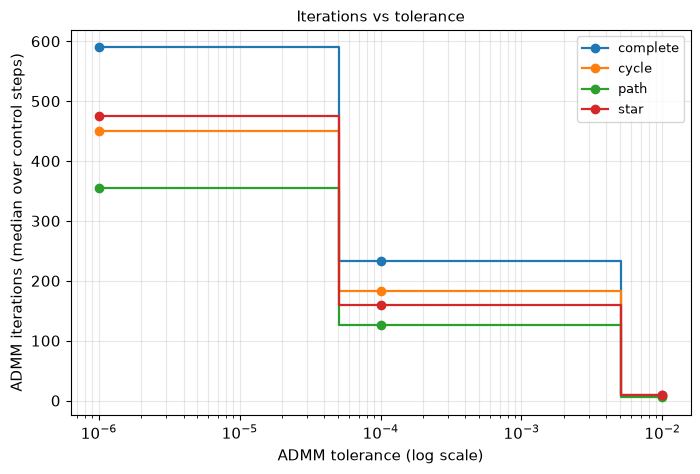

complete  : 1e-2 ->   9.0 iters, 1e-6 -> 590.0 iters (65.6x)
cycle     : 1e-2 ->   8.0 iters, 1e-6 -> 449.5 iters (56.2x)
path      : 1e-2 ->   5.5 iters, 1e-6 -> 354.5 iters (64.5x)
star      : 1e-2 ->   8.5 iters, 1e-6 -> 476.0 iters (56.0x)


In [3]:
tolerances = [1e-2, 1e-4, 1e-6]
tolerance_labels = ["1e-2", "1e-4", "1e-6"]
exp_of_tol = {"2": 1e-2, "4": 1e-4, "6": 1e-6}

fig, ax = plt.subplots(figsize=(8, 5))
for topo, by_exp in tol_logs.items():
    iters = []
    for exp in sorted(by_exp, key=int):
        log = by_exp[exp]
        # Median across the control steps is robust to the first-step transient.
        iters.append(float(np.median(log.admm_iterations)))
    if len(iters) != len(tolerances):
        # Partial data (CI subset): plot what we have rather than fabricating a point.
        xs = [exp_of_tol[e] for e in sorted(by_exp, key=int)]
    else:
        xs = tolerances
        iters = iters
    ax.step(xs, iters, where="mid", marker="o", linewidth=1.6, label=topo)

ax.set_xscale("log")
ax.set_xlabel("ADMM tolerance (log scale)")
ax.set_ylabel("ADMM iterations (median over control steps)")
ax.set_title("Iterations vs tolerance")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize="small")
plt.show()

for topo, by_exp in tol_logs.items():
    lo = by_exp.get("2")
    hi = by_exp.get("6")
    if lo is not None and hi is not None:
        print(
            f"{topo:10s}: 1e-2 -> {np.median(lo.admm_iterations):5.1f} iters, "
            f"1e-6 -> {np.median(hi.admm_iterations):5.1f} iters "
            f"({np.median(hi.admm_iterations) / max(np.median(lo.admm_iterations), 1):.1f}x)"
        )


## Warm start payoff

Iterations at each control step, cold versus warm start.

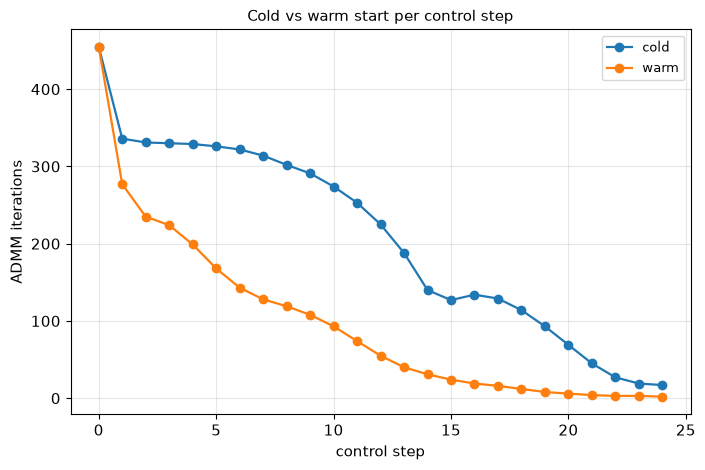

mean cold/warm ratio after step 5: 5.98
median iterations  warm=27.5  cold=137.0


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for mode, log in warm_logs.items():
    ax.plot(
        np.arange(len(log.admm_iterations)),
        log.admm_iterations,
        marker="o",
        linewidth=1.6,
        label=mode,
    )
ax.set_xlabel("control step")
ax.set_ylabel("ADMM iterations")
ax.set_title("Cold vs warm start per control step")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize="small")
plt.show()

warm = warm_logs.get("warm")
cold = warm_logs.get("cold")
if warm is not None and cold is not None:
    # Skip the transient head: the steady-state payoff is what matters for MPC.
    ratio = cold.admm_iterations[5:] / np.maximum(warm.admm_iterations[5:], 1)
    print(f"mean cold/warm ratio after step 5: {ratio.mean():.2f}")
    print(f"median iterations  warm={np.median(warm.admm_iterations[5:]):.1f}  "
          f"cold={np.median(cold.admm_iterations[5:]):.1f}")


## Real-time budget

Given a control period, how many iterations fit? Overlay the budget line on the measured per-iteration time to read off the achievable rate.

mean solve time per control step: 0.9911 s
mean time per ADMM iteration: 0.0101 s


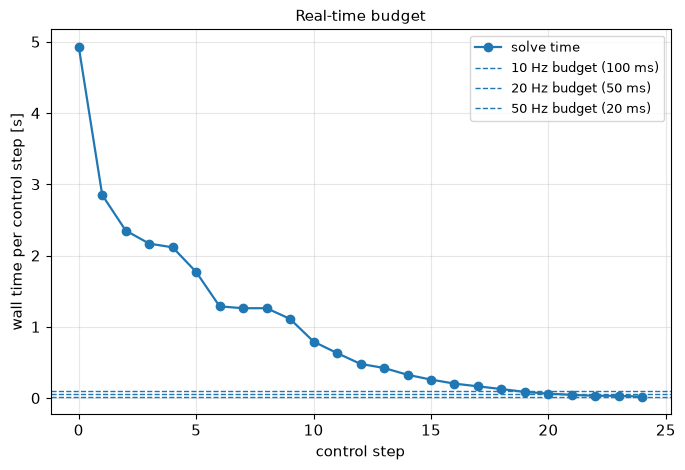

10 Hz:  100 ms budget -> ~  9 ADMM iterations fit
20 Hz:   50 ms budget -> ~  4 ADMM iterations fit
50 Hz:   20 ms budget -> ~  1 ADMM iterations fit


In [5]:
# Use a warm log for the per-iteration timing (the representative closed-loop case).
log = warm_logs.get("warm") or next(iter(tol_logs["cycle"].values()))
solve_times = np.asarray(log.solve_times)
per_iteration = np.array(
    [np.mean(h.iteration_time) for h in log.histories if h.iteration_time]
)
print(f"mean solve time per control step: {solve_times.mean():.4f} s")
print(f"mean time per ADMM iteration: {per_iteration.mean():.4f} s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(len(solve_times)), solve_times, marker="o", linewidth=1.6, label="solve time")
for hz in (10, 20, 50):
    budget = 1.0 / hz
    ax.axhline(budget, linestyle="--", linewidth=1.0,
               label=f"{hz} Hz budget ({budget * 1000:.0f} ms)")
ax.set_xlabel("control step")
ax.set_ylabel("wall time per control step [s]")
ax.set_title("Real-time budget")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize="small")
plt.show()

if per_iteration.size:
    for hz in (10, 20, 50):
        budget = 1.0 / hz
        fit = int(np.floor(budget / per_iteration.mean()))
        print(f"{hz:2d} Hz: {budget * 1000:4.0f} ms budget -> ~{fit:3d} ADMM iterations fit")


## Takeaway

Fixed low iteration budgets are viable in closed loop once warm starting is on.